In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load Data
df = pd.read_csv('fraud_data_cleanned.csv')
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,CUST_1001,64,Male,Germany,112.85,9,73,0,Electronics,50.5,51,0.37,1569
1,CUST_1001,35,Male,UK,252.38,13,224,0,Fashion,86.8,99,0.15,2193
2,CUST_1002,40,Female,Germany,90.38,7,255,1,Beauty,63.4,92,0.10,2215
3,CUST_1004,73,Female,Germany,94.98,9,150,0,Fashion,32.0,49,0.20,2185
4,CUST_1005,43,Male,USA,27.50,10,150,0,Beauty,76.6,13,0.14,1037


In [45]:
print("Shape:", df.shape)
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Target Class Distribution ---")
print(df['is_fraudulent'].value_counts(normalize=True) * 100)


Shape: (5000, 13)

--- Missing Values ---
customer_id             0
age                     0
gender                  0
country                 0
avg_order_value         0
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate         0
loyalty_score           0
churn_risk              0
customer_tenure_days    0
dtype: int64

--- Target Class Distribution ---
is_fraudulent
0    97.42
1     2.58
Name: proportion, dtype: float64


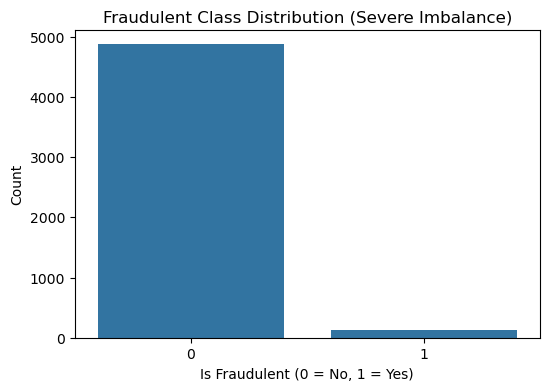

In [46]:
# target ka graph bhi bana kr dekh lete hain
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraudulent', data=df)
plt.title('Fraudulent Class Distribution (Severe Imbalance)')
plt.xlabel('Is Fraudulent (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [49]:
X = df.drop(columns=['customer_id', 'is_fraudulent'])
y = df['is_fraudulent']

In [51]:
# let enode and fix something before puting 
# in making it ready for machine laerning

num_col = X.select_dtypes(include=['int16', 'float64'])
cat_col = ['gender', 'counter', 'preferred_category']

In [52]:
print('numerical columns' , num_col)
print('categorcal columns' , cat_col)

numerical columns       avg_order_value  email_open_rate  churn_risk
0              112.85            50.50        0.37
1              252.38            86.80        0.15
2               90.38            63.40        0.10
3               94.98            32.00        0.20
4               27.50            76.60        0.14
...               ...              ...         ...
4995           200.68            41.60        0.30
4996           175.24            50.95        0.51
4997            62.08            97.20        0.41
4998           107.24            67.00        0.22
4999            39.24            32.50        0.18

[5000 rows x 3 columns]
categorcal columns ['gender', 'counter', 'preferred_category']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_col)
    ]
)

X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed)

ValueError: No valid specification of the columns. Only a scalar, list or slice of all integers or all strings, or boolean mask is allowed

In [58]:
X.head()

,age,gender,country,avg_order_value,total_orders,last_purchase,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,64,Male,Germany,112.85,9,73,Electronics,50.5,51,0.37,1569
1,35,Male,UK,252.38,13,224,Fashion,86.8,99,0.15,2193
2,40,Female,Germany,90.38,7,255,Beauty,63.4,92,0.10,2215
3,73,Female,Germany,94.98,9,150,Fashion,32.0,49,0.20,2185
4,43,Male,USA,27.50,10,150,Beauty,76.6,13,0.14,1037
